# 04 · Customer Analysis

**Phase 5 of the brief.** Who are these customers and how do they behave?

A constraint worth stating first: **there is no customer table in this dataset.** No
demographics, no signup date, no location, no spend. Every customer attribute used here is
derived from their order history in notebook 02. That rules out demographic segmentation
entirely and makes *behavioural* segmentation the only honest option.

A second constraint: because order histories are truncated at 100 orders and the dataset
has no calendar dates, we cannot distinguish "a customer who left" from "a customer whose
history ends where the extract ends". Churn is therefore discussed as *order interval*,
never as a churn rate.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import instacart as ic, analysis as an
plt = ic.set_style()
pd.set_option("display.width", 180, "display.max_columns", 40)

customers = ic.load_clean("customers")
orders = ic.load_clean("orders_clean")
print(f"{len(customers):,} customers | {len(orders):,} orders")
display(customers.head(3))

206,209 customers | 3,421,083 orders


,user_id,n_orders_total,mean_dspo,median_dspo,fav_dow,fav_hour,n_orders_observed,total_items,avg_basket,median_basket,max_basket,items_reordered,reorder_rate,distinct_products,repeat_breadth
0,1,11,19.000000,19.5,4,7,11,70.0,6.363636,6.0,11.0,51.0,0.728571,19,0.271429
1,2,15,16.285715,13.0,1,10,15,226.0,15.066667,14.0,31.0,105.0,0.464602,121,0.535398
2,3,13,12.000000,11.0,0,16,12,88.0,7.333333,7.0,11.0,55.0,0.625000,33,0.375000


## 4.1 Order frequency

*Questions from the brief: what is the average order count? how is it distributed? how many
customers order heavily? are there distinct groups?*

In [2]:
s = customers.n_orders_total
freq_stats = pd.DataFrame({"statistic": ["mean","median","p25","p75","p90","p99","max","skew"],
                           "orders per customer": [s.mean(), s.median(), s.quantile(.25), s.quantile(.75),
                                                   s.quantile(.90), s.quantile(.99), s.max(), s.skew()]})
display(freq_stats.round(2))
print("mean 16.6 vs median 10, skew 2.4 — the average customer is not a real customer.")
print("A quarter of customers have placed 6 orders or fewer; the top 1% have placed 89 or more.")

,statistic,orders per customer
0,mean,16.59
1,median,10.00
2,p25,6.00
3,p75,20.00
4,p90,38.00
5,p99,89.00
6,max,100.00
7,skew,2.40


mean 16.6 vs median 10, skew 2.4 — the average customer is not a real customer.
A quarter of customers have placed 6 orders or fewer; the top 1% have placed 89 or more.


In [3]:
fd = an.order_frequency_dist(customers); ic.savetable(fd, "customer_order_frequency")
display(fd.style.format({"customer_share":"{:.1%}","item_share":"{:.1%}",
                         "avg_basket":"{:.2f}","reorder_rate":"{:.1%}","total_items":"{:,.0f}"}).hide(axis="index"))

  table  -> reports/tables/customer_order_frequency.csv  (6 rows)


bucket,customers,avg_basket,reorder_rate,total_items,customer_share,item_share
3-4 orders,23986,9.60,23.0%,"837,156",11.6%,2.5%
5-6,35755,9.75,29.7%,"1,776,941",17.3%,5.3%
7-10,44772,9.91,38.4%,"3,535,396",21.7%,10.5%
11-20,50965,10.08,49.5%,"7,359,875",24.7%,21.8%
21-50,39821,10.39,62.8%,"12,850,710",19.3%,38.0%
51-100,10910,10.00,73.7%,"7,459,028",5.3%,22.1%


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


  figure -> reports/figures/04_order_frequency.png


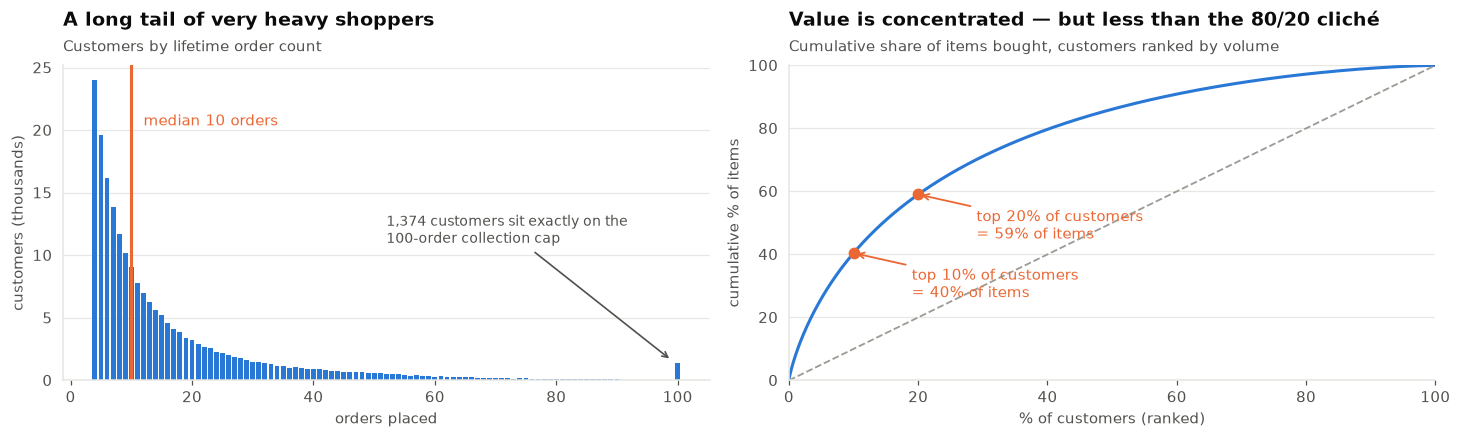

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.1))
h = s.value_counts().sort_index()
axes[0].bar(h.index, h.values/1000, color=ic.PALETTE["s1"])
axes[0].axvline(s.median(), color=ic.PALETTE["s2"], lw=2)
axes[0].text(s.median()+2, h.max()/1000*.85, f"median {s.median():.0f} orders", color=ic.PALETTE["s2"], fontsize=9.5)
axes[0].annotate("1,374 customers sit exactly on the\n100-order collection cap", xy=(99, 1.6),
                 xytext=(52, 11), fontsize=9, color=ic.PALETTE["muted"],
                 arrowprops=dict(arrowstyle="->", color=ic.PALETTE["muted"], lw=1.1))
ic.finish(axes[0], "A long tail of very heavy shoppers",
          "Customers by lifetime order count", "orders placed", "customers (thousands)")

x = np.arange(1, len(customers)+1)/len(customers)*100
cum = customers.sort_values("total_items", ascending=False).total_items.cumsum()/customers.total_items.sum()*100
axes[1].plot(x, cum, color=ic.PALETTE["s1"], lw=2)
axes[1].plot([0,100],[0,100], color=ic.PALETTE["neutral"], ls="--", lw=1.2)
for p, lbl in [(10,"top 10%"), (20,"top 20%")]:
    y = cum.iloc[int(len(customers)*p/100)-1]
    axes[1].scatter([p],[y], color=ic.PALETTE["s2"], s=45, zorder=5)
    axes[1].annotate(f"{lbl} of customers\n= {y:.0f}% of items", xy=(p,y), xytext=(p+9, y-14),
                     fontsize=9.5, color=ic.PALETTE["s2"],
                     arrowprops=dict(arrowstyle="->", color=ic.PALETTE["s2"], lw=1.2))
ic.finish(axes[1], "Value is concentrated — but less than the 80/20 cliché",
          "Cumulative share of items bought, customers ranked by volume",
          "% of customers (ranked)", "cumulative % of items")
axes[1].set_xlim(0,100); axes[1].set_ylim(0,100)
fig.tight_layout(); ic.savefig(fig, "04_order_frequency"); plt.show()

**Finding.** Customers place a median of **10 orders** (mean 16.6, skew 2.4). The
distribution has no natural break — it decays smoothly — which already warns that any
segmentation will be a management convenience rather than a discovered truth.

Concentration is real but moderate: the **top 10% of customers buy 35.1%** of all items and
the top 20% buy **53.7%**. This is *not* an 80/20 business — the bottom half of customers
still accounts for 17.8% of volume. Practically: a retention programme aimed only at the
top decile would leave most of the volume untouched, so the bigger prize is moving the
large middle (the 7–20 order customers, 46% of customers and 32% of items) up one band.

And the bands differ on far more than order count:

In [5]:
bb = customers.assign(b=pd.cut(customers.n_orders_total,[0,4,6,10,20,50,101],
        labels=["3-4","5-6","7-10","11-20","21-50","51-100"])).groupby("b", observed=True).agg(
        customers=("user_id","size"), avg_basket=("avg_basket","mean"), reorder_rate=("reorder_rate","mean"),
        distinct_products=("distinct_products","mean"), avg_interval=("mean_dspo","mean"))
display(bb.round(2))
print("Basket size barely moves across the bands (9.6 → 10.4 items).")
print("Reorder rate TRIPLES (23.0% → 73.7%) and the interval nearly quarters (20.3 → 5.1 days).")
print("=> Heavy customers are not customers who buy more per trip. They are customers who")
print("   come back sooner, and buy the same things when they do.")

,customers,avg_basket,reorder_rate,distinct_products,avg_interval
b,,,,,
3-4,23986,9.60,0.23,26.53,20.290001
5-6,35755,9.75,0.30,34.38,19.330000
7-10,44772,9.91,0.38,47.41,17.760000
11-20,50965,10.08,0.49,70.19,14.860000
21-50,39821,10.39,0.63,111.61,10.020000
51-100,10910,10.00,0.74,169.81,5.130000


Basket size barely moves across the bands (9.6 → 10.4 items).
Reorder rate TRIPLES (23.0% → 73.7%) and the interval nearly quarters (20.3 → 5.1 days).
=> Heavy customers are not customers who buy more per trip. They are customers who
   come back sooner, and buy the same things when they do.


## 4.2 Basket size

*Questions: average items per order, its distribution, and its relationship to order count.*

In [6]:
known = orders[orders.has_basket_data]
bstats = pd.DataFrame({"statistic":["mean","median","p25","p75","p90","p99","max","skew"],
                       "items per order":[known.basket_size.mean(), known.basket_size.median(),
                                          known.basket_size.quantile(.25), known.basket_size.quantile(.75),
                                          known.basket_size.quantile(.90), known.basket_size.quantile(.99),
                                          known.basket_size.max(), known.basket_size.skew()]})
display(bstats.round(2))

,statistic,items per order
0,mean,10.11
1,median,8.00
2,p25,5.00
3,p75,14.00
4,p90,20.00
5,p99,35.00
6,max,145.00
7,skew,1.56


  figure -> reports/figures/04_basket_vs_frequency.png


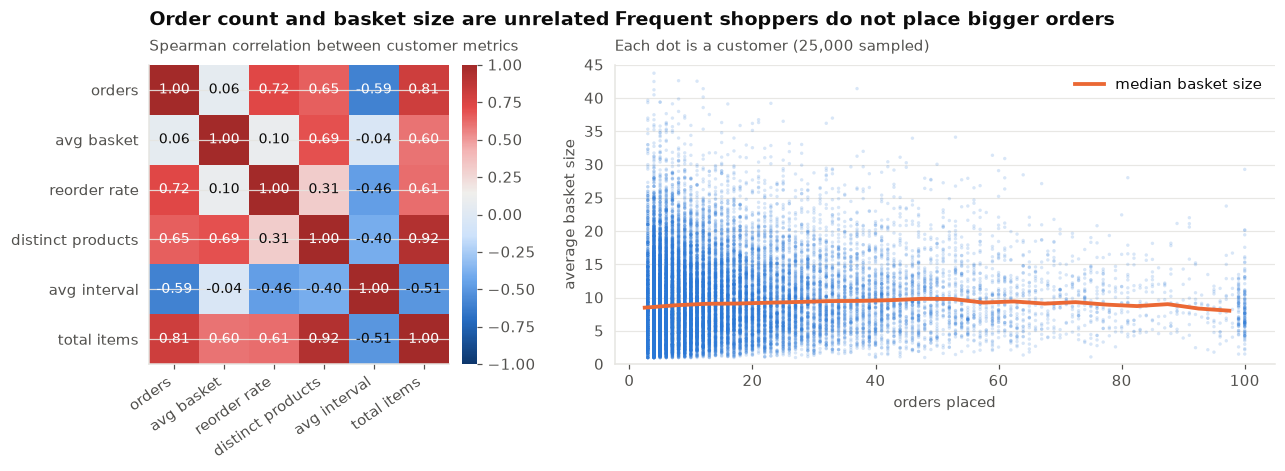

In [7]:
corr = customers[["n_orders_observed","avg_basket","reorder_rate","distinct_products","mean_dspo","total_items"]]
sp = corr.corr(method="spearman")
fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.4))
im = axes[0].imshow(sp.values, cmap=ic.div_cmap(), vmin=-1, vmax=1)
lbl = ["orders","avg basket","reorder rate","distinct products","avg interval","total items"]
axes[0].set_xticks(range(6)); axes[0].set_xticklabels(lbl, rotation=35, ha="right")
axes[0].set_yticks(range(6)); axes[0].set_yticklabels(lbl)
for i in range(6):
    for j in range(6):
        v = sp.values[i,j]
        axes[0].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                     color="white" if abs(v)>.55 else ic.PALETTE["ink"])
axes[0].grid(False)
cb = fig.colorbar(im, ax=axes[0], pad=.02, fraction=.046); cb.outline.set_visible(False)
ic.finish(axes[0], "Order count and basket size are unrelated",
          "Spearman correlation between customer metrics", "", "")

samp = customers.sample(25000, random_state=42)
axes[1].scatter(samp.n_orders_observed, samp.avg_basket, s=5, alpha=.18,
                color=ic.PALETTE["s1"], edgecolors="none")
med = customers.groupby(pd.cut(customers.n_orders_observed, range(0,101,5))).avg_basket.median()
xs = [i.mid for i in med.index]
axes[1].plot(xs, med.values, color=ic.PALETTE["s2"], lw=2.5, label="median basket size")
axes[1].legend(loc="upper right")
ic.finish(axes[1], "Frequent shoppers do not place bigger orders",
          "Each dot is a customer (25,000 sampled)", "orders placed", "average basket size")
axes[1].set_ylim(0, 45)
fig.tight_layout(); ic.savefig(fig, "04_basket_vs_frequency"); plt.show()

**Finding — a genuinely useful negative result.** The correlation between how often a
customer orders and how large their basket is, is **0.06 (Spearman) — effectively zero**.
The median line is flat across the whole range.

Order frequency and basket size are **two independent levers**. A customer who orders 40
times a year with a 10-item basket and one who orders 10 times with a 10-item basket are
not on a single "engagement" scale; they are different behaviours that must be grown
differently. This also means a single "customer value score" built by multiplying the two
would hide which lever is actually movable for a given customer.

What *does* move with order count is **reorder rate (ρ = 0.73)** and, negatively,
**order interval (ρ = −0.60)**. Loyalty here means *frequency and repetition*, not size.

## 4.3 Customer segmentation

The brief asks for segmentation on three dimensions: **number of orders, average basket
size, reorder rate**. Two preparation decisions:

1. **Log-transform order count.** It is skewed 2.4; left raw, the handful of 100-order
   customers would dominate Euclidean distance and the clusters would be "very heavy" vs
   "everyone else".
2. **Standardise all three**, because they are on different units (orders, items, a proportion).

And then the question that most segmentations skip: *how many clusters does the data
actually support?*

  table  -> reports/tables/segmentation_k_scan.csv  (6 rows)


,k,inertia,silhouette
0,2,368658.8551,0.3654
1,3,274331.2596,0.3557
2,4,221761.6996,0.3008
3,5,191988.2713,0.2928
4,6,172095.0777,0.2809
5,7,154751.9151,0.2761


  figure -> reports/figures/04_segmentation_scan.png


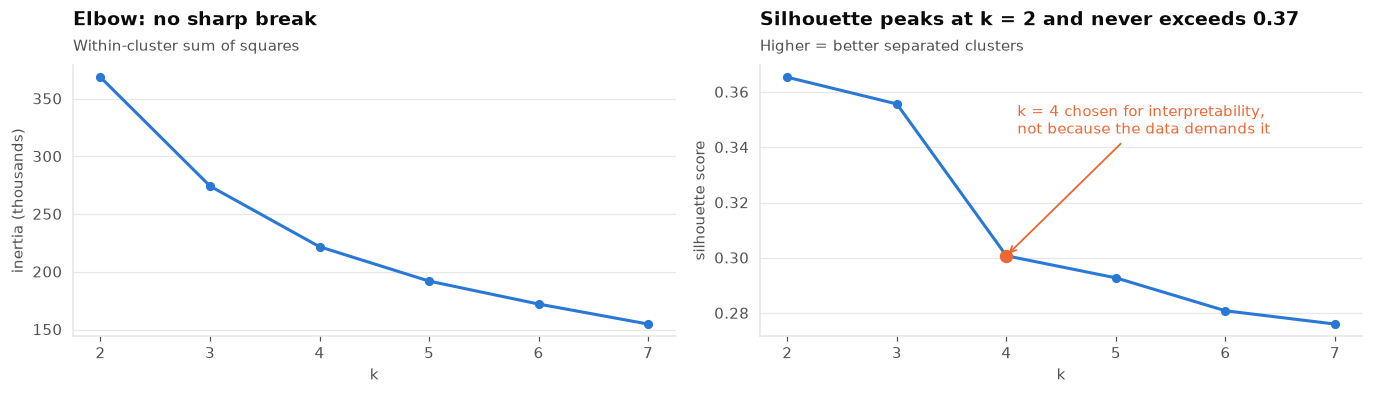

In [8]:
scan = an.segment_scan(customers); ic.savetable(scan, "segmentation_k_scan")
display(scan.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12.6, 3.7))
axes[0].plot(scan.k, scan.inertia/1000, color=ic.PALETTE["s1"], lw=2, marker="o", ms=5)
ic.finish(axes[0], "Elbow: no sharp break", "Within-cluster sum of squares", "k", "inertia (thousands)")
axes[1].plot(scan.k, scan.silhouette, color=ic.PALETTE["s1"], lw=2, marker="o", ms=5)
axes[1].scatter([4],[scan.loc[scan.k==4,"silhouette"].iat[0]], color=ic.PALETTE["s2"], s=60, zorder=5)
axes[1].annotate("k = 4 chosen for interpretability,\nnot because the data demands it",
                 xy=(4, scan.loc[scan.k==4,"silhouette"].iat[0]), xytext=(4.1, .345),
                 fontsize=9.5, color=ic.PALETTE["s2"],
                 arrowprops=dict(arrowstyle="->", color=ic.PALETTE["s2"], lw=1.2))
ic.finish(axes[1], "Silhouette peaks at k = 2 and never exceeds 0.37",
          "Higher = better separated clusters", "k", "silhouette score")
fig.tight_layout(); ic.savefig(fig, "04_segmentation_scan"); plt.show()

**An honest reading of the diagnostics.** The silhouette score peaks at **k = 2 (0.365)**
and declines from there; the elbow curve bends smoothly with no clear break. Scores in the
0.29–0.37 range mean **weak cluster structure** — this customer base is a continuum, not a
set of natural tribes.

So the segmentation below is presented for what it is: **a deliberate partition of a
continuous space into four bands that are useful to act on**, not a discovery of hidden
groups. k = 2 would be statistically tidier and commercially useless ("light" and "heavy").
k = 4 separates the two independent levers found in §4.2 — frequency and basket size — into
segments that call for different interventions. That is the reason, and it is a judgement
call, stated as one.

In [9]:
labels, Xs, km = an.segment_customers(customers, k=4)
customers["segment_id"] = labels
prof = an.segment_profile(customers, "segment_id")
display(prof.round(3))

,segment_id,customers,avg_orders,med_orders,avg_basket,reorder_rate,avg_interval,distinct_products,total_items,customer_share,item_share,items_per_customer
0,0,44475,40.571,35.0,10.143,0.690,8.843,118.891,18066844.0,0.216,0.534,406.225
1,1,65718,5.744,5.0,8.037,0.223,19.108,35.207,3012083.0,0.319,0.089,45.833
2,2,33020,10.623,9.0,19.356,0.462,16.851,98.050,6967030.0,0.160,0.206,210.994
3,3,62996,12.912,12.0,6.992,0.493,15.559,47.995,5773149.0,0.305,0.171,91.643


In [10]:
# Name the segments from their own profile rather than by eye, so the labels can't drift.
p = prof.set_index("segment_id")
names = {}
names[p.avg_orders.idxmax()] = "Loyal Regulars"
names[p.avg_basket.idxmax()] = "Big-Basket Stockers"
rest = [i for i in p.index if i not in names]
rest_sorted = p.loc[rest].sort_values("reorder_rate")
names[rest_sorted.index[0]] = "Occasional / At-Risk"
names[rest_sorted.index[1]] = "Steady Small-Basket"
customers["segment"] = customers.segment_id.map(names)
prof = an.segment_profile(customers, "segment")
order = ["Loyal Regulars","Big-Basket Stockers","Steady Small-Basket","Occasional / At-Risk"]
prof = prof.set_index("segment").loc[order].reset_index()
ic.savetable(prof, "customer_segments")
display(prof.style.format({"customers":"{:,.0f}","avg_orders":"{:.1f}","med_orders":"{:.0f}",
                           "avg_basket":"{:.1f}","reorder_rate":"{:.1%}","avg_interval":"{:.1f}",
                           "distinct_products":"{:.0f}","total_items":"{:,.0f}",
                           "customer_share":"{:.1%}","item_share":"{:.1%}",
                           "items_per_customer":"{:.0f}"}).hide(axis="index"))

  table  -> reports/tables/customer_segments.csv  (4 rows)


segment,customers,avg_orders,med_orders,avg_basket,reorder_rate,avg_interval,distinct_products,total_items,customer_share,item_share,items_per_customer
Loyal Regulars,"44,475",40.6,35,10.1,69.0%,8.8,119,"18,066,844",21.6%,53.4%,406
Big-Basket Stockers,"33,020",10.6,9,19.4,46.2%,16.9,98,"6,967,030",16.0%,20.6%,211
Steady Small-Basket,"62,996",12.9,12,7.0,49.3%,15.6,48,"5,773,149",30.5%,17.1%,92
Occasional / At-Risk,"65,718",5.7,5,8.0,22.3%,19.1,35,"3,012,083",31.9%,8.9%,46


  figure -> reports/figures/04_segment_profiles.png


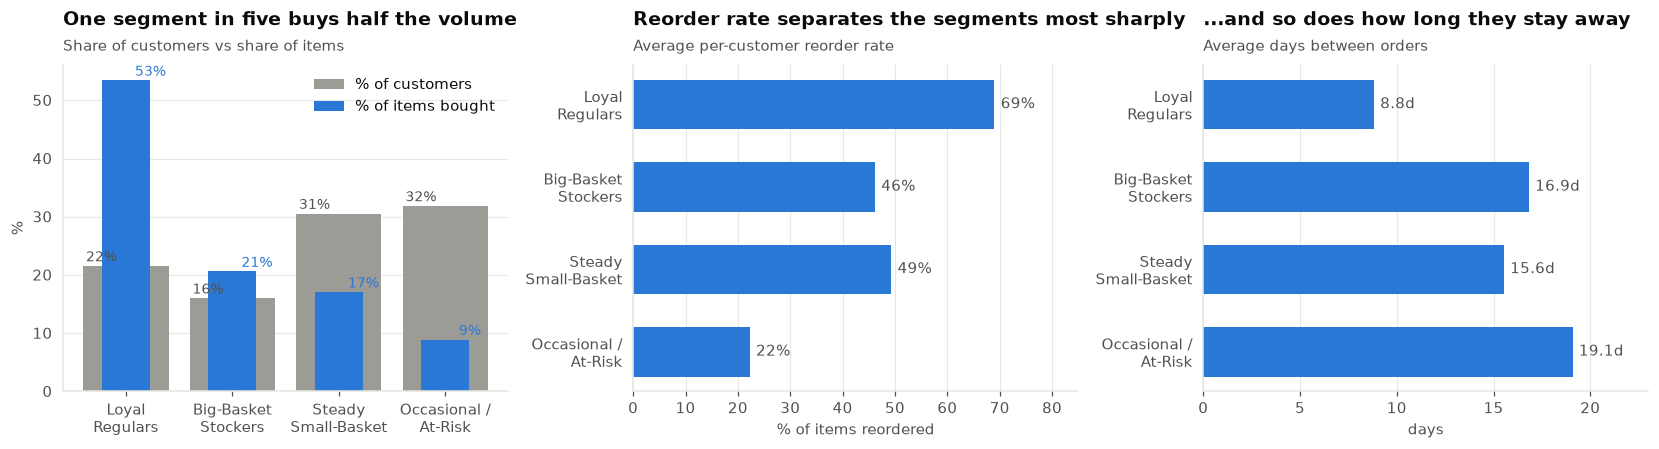

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.2))
cols = [ic.PALETTE["s1"], ic.PALETTE["s2"], ic.PALETTE["s3"], ic.PALETTE["s4"]]
short = ["Loyal\nRegulars","Big-Basket\nStockers","Steady\nSmall-Basket","Occasional /\nAt-Risk"]

axes[0].bar(short, prof.customer_share*100, color=ic.PALETTE["neutral"], label="% of customers")
axes[0].bar(short, prof.item_share*100, color=ic.PALETTE["s1"], width=.45, label="% of items bought")
for i,(c,v) in enumerate(zip(prof.customer_share*100, prof.item_share*100)):
    axes[0].text(i-.23, c+.8, f"{c:.0f}%", ha="center", fontsize=9, color=ic.PALETTE["muted"])
    axes[0].text(i+.23, v+.8, f"{v:.0f}%", ha="center", fontsize=9, color=ic.PALETTE["s1"])
axes[0].legend(loc="upper right")
ic.finish(axes[0], "One segment in five buys half the volume",
          "Share of customers vs share of items", "", "%")

axes[1].barh(short[::-1], prof.reorder_rate.values[::-1]*100, color=ic.PALETTE["s1"], height=.6)
for i, v in enumerate(prof.reorder_rate.values[::-1]*100):
    axes[1].text(v+1.2, i, f"{v:.0f}%", va="center", fontsize=9.5, color=ic.PALETTE["muted"])
ic.finish(axes[1], "Reorder rate separates the segments most sharply",
          "Average per-customer reorder rate", "% of items reordered", "", xgrid=True)
axes[1].set_xlim(0, 85)

axes[2].barh(short[::-1], prof.avg_interval.values[::-1], color=ic.PALETTE["s1"], height=.6)
for i, v in enumerate(prof.avg_interval.values[::-1]):
    axes[2].text(v+.3, i, f"{v:.1f}d", va="center", fontsize=9.5, color=ic.PALETTE["muted"])
ic.finish(axes[2], "...and so does how long they stay away",
          "Average days between orders", "days", "", xgrid=True)
axes[2].set_xlim(0, 23)
fig.tight_layout(); ic.savefig(fig, "04_segment_profiles"); plt.show()

### Segment characteristics

| Segment | Customers | Share of items | Orders | Basket | Reorder rate | Interval | What it is |
|---|---|---|---|---|---|---|---|
| **Loyal Regulars** | 44,475 (21.6%) | **53.4%** | 40.6 | 10.1 | **69.0%** | 8.8 d | The business. Order every ~9 days, buy mostly their usual list, and buy half of everything sold. |
| **Big-Basket Stockers** | 33,020 (16.0%) | 20.6% | 10.6 | **19.4** | 46.2% | 16.9 d | Fortnightly stock-up shoppers. Twice the basket, a third of the frequency. |
| **Steady Small-Basket** | 62,996 (30.5%) | 17.1% | 12.9 | **7.0** | 49.3% | 15.6 d | Regular but light — top-ups rather than a main shop. |
| **Occasional / At-Risk** | 65,718 (31.9%) | 8.9% | 5.7 | 8.0 | **22.3%** | **19.1 d** | A third of the customer base producing a twelfth of the volume. Habit never formed. |

The two middle segments are exactly the independence found in §4.2 made visible: same
rough order count, opposite basket sizes, and therefore opposite growth levers —
Small-Basket customers need *basket building*, Stockers need *frequency*.

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


  figure -> reports/figures/04_segment_scatter.png


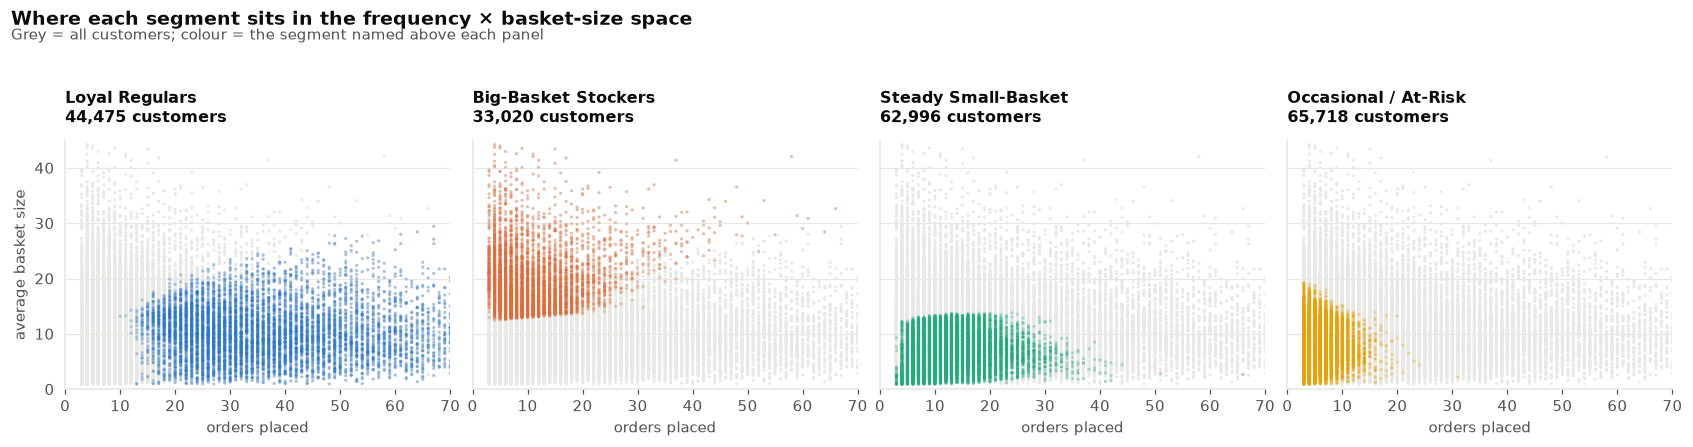

In [12]:
# Small multiples rather than one four-colour scatter: with four categories a single
# scatter cannot keep the colours separable for colour-vision-deficient readers.
fig, axes = plt.subplots(1, 4, figsize=(15.4, 3.8), sharex=True, sharey=True)
samp = customers.sample(40000, random_state=42)
for ax, (nm, col) in zip(axes, zip(order, cols)):
    ax.scatter(samp.n_orders_observed, samp.avg_basket, s=4, color="#E8E8E4", edgecolors="none")
    sub = samp[samp.segment == nm]
    ax.scatter(sub.n_orders_observed, sub.avg_basket, s=4, color=col, alpha=.35, edgecolors="none")
    ax.set_title(f"{nm}\n{len(customers[customers.segment==nm]):,} customers", fontsize=10.5)
    ax.set_xlabel("orders placed"); ax.grid(axis="y", alpha=.9); ax.set_axisbelow(True)
axes[0].set_ylabel("average basket size")
axes[0].set_ylim(0, 45); axes[0].set_xlim(0, 70)
fig.suptitle("Where each segment sits in the frequency × basket-size space", x=.009, ha="left",
             fontsize=12.5, fontweight="600", y=1.06)
fig.text(.009, .99, "Grey = all customers; colour = the segment named above each panel",
         fontsize=9.5, color=ic.PALETTE["muted"])
fig.tight_layout(); ic.savefig(fig, "04_segment_scatter"); plt.show()

In [13]:
customers.to_parquet(ic.PROC/"customers.parquet", index=False)
print("segment labels written back to data/processed/customers.parquet")

segment labels written back to data/processed/customers.parquet


## 4.4 What this means for retention

`Finding → Evidence → Business meaning`, the structure the brief asks for.

**Finding 1 — Loyalty is frequency, not basket size.**
*Evidence:* ρ(orders, basket size) = 0.06; ρ(orders, reorder rate) = 0.73; across order
bands the basket moves 9.6 → 10.4 items while the reorder rate moves 23% → 74% and the
interval falls 20.3 → 5.1 days.
*Business meaning:* retention effort should target **the gap between orders**, not the size
of the order. A "spend $10 more" promotion pushes the lever that doesn't move.

**Finding 2 — A third of customers never form the habit.**
*Evidence:* Occasional / At-Risk is 31.9% of customers but 8.9% of items, with a 22.3%
reorder rate and a 19.1-day interval.
*Business meaning:* the reorder rate by order number (notebook 03) shows the habit forms
between orders 2 and 6, where the rate climbs 27% → 54%. That is the window where
intervention is worth paying for; after order 10 the customer is already retained.

**Finding 3 — The two middle segments need opposite treatments.**
*Evidence:* Steady Small-Basket (7.0 items, 12.9 orders) and Big-Basket Stockers (19.4
items, 10.6 orders) have almost the same order count and nearly 3x different baskets.
*Business meaning:* one generic "engagement" campaign is wrong for both. Small-Basket
customers are a cross-sell and basket-building opportunity (notebook 06 supplies the
product pairs); Stockers are a scheduling opportunity — their 16.9-day interval against a
19.4-item basket suggests a replenishment reminder, not a bigger cart.

**Caveat carried forward.** These segments are a partition of a continuum (silhouette
≤ 0.37), so they should be used to organise action, not quoted as if customers naturally
fall into four types. Segment boundaries will shift if the clustering is re-run on new data.